<a href="https://colab.research.google.com/github/rostovcevartem209/Pandas/blob/main/Pandas_teach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd

countries = pd.Series(
    data = ['Англия', 'Канада', 'США', 'Россия', 'Украина', 'Беларусь', 'Казахстан'],
    index = ['UK', 'CA', 'US', 'RU', 'UA', 'BY', 'KZ'],
    name = 'Страны'
)
countries

#создание при помощи словаря
countries = pd.Series({
    'UK': 'Англия',
    'CA': 'Канада',
    'US': 'США',
    'RU': 'Россия',
    'BY': 'Беларусь',
    'KZ': 'Казахстан'},
    name = 'countries'
)
countries.loc[['UK', 'US', 'CA']] #доступ по ключам
countries.iloc[[1,4]] #доступ по порядковым номерам

,countries
CA,Канада
BY,Беларусь


DATAFRAME

In [20]:
#задаем словарем, где ключи - название столбцов, списки - строки
countries_df = pd.DataFrame({
    'country': ['Англия', 'Канада', 'США', 'Россия', 'Беларусь', 'Казахстан'],
    'population': [56.29, 38.05, 322.28, 146.24,  9.5, 17.04],
    'area': [133396, 9984670, 9826630, 17125191, 207600, 2724902]
})

countries_df.index = ['UK', 'CA', 'US', 'RU', 'BY', 'KZ'] #задаем индексы
countries_df

#создание из вложенного списка
countries_df = pd.DataFrame(
        data = [
        ['Англия', 56.29, 133396],
        ['Канада', 38.05, 9984670],
        ['США', 322.28, 9826630],
        ['Россия', 146.24, 17125191],
        ['Беларусь', 9.5, 207600],
        ['Казахстан', 17.04, 2724902]
    ],
        columns = ['COUNTRIES', 'POPULATION', 'AREA'],
        index = ['UK', 'CA', 'US', 'RU', 'BY', 'KZ'],
)
# Среднее по каждому столбцу (axis=0)
countries_df.mean(axis=0, numeric_only=True) #numeric_only - означает что вычесления производятся только для числовых значений

countries_df.POPULATION #доступ к столбцу по названию
countries_df['AREA']

#доступ к конкретным ячейкам
countries_df.loc['UK', 'AREA']
countries_df.loc['RU', ['POPULATION', 'AREA']]
countries_df.loc[['BY', 'KZ'], ['POPULATION', 'AREA']]
countries_df.iloc[2:7,1:3]

,POPULATION,AREA
US,322.28,9826630
RU,146.24,17125191
BY,9.50,207600
KZ,17.04,2724902


РАБОТА С ФАЙЛАМИ

In [21]:
!mkdir data
countries_df = pd.DataFrame({
    'country': ['Англия', 'Канада', 'США', 'Россия', 'Украина', 'Беларусь', 'Казахстан'],
    'population': [56.29, 38.05, 322.28, 146.24, 45.5, 9.5, 17.04],  # население в млн
    'area': [133396, 9984670, 9826630, 17125191, 603628, 207600, 2724902]  # площадь в км²
})
countries_df.to_csv('data/countries.csv', index=False, sep=';') #загрузка в папку дата csv файла

countries_data = pd.read_csv('/content/data/countries.csv', sep = ';') #выгрузка из папки data csv файла
countries_data

data = pd.read_csv('https://raw.githubusercontent.com/esabunor/MLWorkspace/master/melb_data.csv') #загрузка файла по ссылке из интернета
data.head()  # выводим первые строки для проверки

# Сохранение в Excel
countries_df.to_excel('data/countries.xlsx', index=False)

# Чтение из Excel
excel_data = pd.read_excel('data/countries.xlsx')

mkdir: cannot create directory ‘data’: File exists


РЕАЛЬНЫЙ ДАТАСЕТ

In [22]:
# Загрузка данных по ссылке
melb_data = pd.read_csv('https://raw.githubusercontent.com/esabunor/MLWorkspace/master/melb_data.csv')

mask = melb_data['Price']>2000000
melb_data[mask].head()

#найдем количество трехкомнатных квартир
melb_data[melb_data['Rooms']==3].shape[0]

#найдем трехкомнатные кватриры дешевле 300 тыс.
melb_data[(melb_data['Rooms']==3) & (melb_data['Price']<300000)].shape[0]

#объекты дешевле 300 тысяч, у которых либо 3 комнаты, либо площадь больше 100 м²
melb_data[(melb_data['Price']<300000) & ((melb_data['Rooms']==3)|(melb_data['BuildingArea']>100))].shape[0]

#Максимальное количество комнат в таунхаусах
melb_data[melb_data['Type']=='t']['Rooms'].max()

#Медианная площадь объектов дороже среднего
mean_price = melb_data['Price'].mean()
melb_data[melb_data['Price']>mean_price]['BuildingArea'].median()

melb_data[melb_data['Bathroom']==0].shape[0]
melb_data[(melb_data['SellerG']=='Nelson')&(melb_data['Price']>3000000)].shape[0]
melb_data[melb_data['BuildingArea']==0]['Price'].min()

#Какова средняя цена объектов недвижимости в таблице melb_data с ценой менее одного миллиона, в которых либо количество комнат больше пяти, либо здание моложе 2015 года?
melb_data[(melb_data['Price']<1000000)&((melb_data['Rooms']>5)|(melb_data['YearBuilt']>2015))]['Price'].mean()

#В каком районе Мельбурна чаще всего продаются виллы и коттеджи (тип здания — h) с ценой меньше трёх миллионов?
#ПРИ ПОМОЩИ СЛОВАРЯ
lst = list(melb_data[(melb_data['Type']=='h')&(melb_data['Price']<3000000)]['Regionname'])
dict = {}
for i in set(lst):
  dict[lst.count(i)] = i
print(max(dict))

#БЕЗ СЛОВАРЯ
melb_data[(melb_data['Type']=='h')&(melb_data['Price']<3000000)]['Regionname'].value_counts()[0]

3451


/tmp/ipykernel_13640/2388661138.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  melb_data[(melb_data['Type']=='h')&(melb_data['Price']<3000000)]['Regionname'].value_counts()[0]


np.int64(3451)

ИССЛЕДОВАНИЕ СТРУКТУРЫ ДАННЫХ DATAFRAME

In [23]:
melb_data = melb_data.dropna(subset=['Bathroom']) # Удаляем пропуски в нужном столбце
melb_data['Bathroom'] = melb_data['Bathroom'].astype('int64')
# melb_data.info()

melb_data.describe().loc[:, ['Distance', 'BuildingArea', 'Price']]

melb_data.describe(include=['object'])

,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,14925,14925,14925,14925,14925,14925,12233,14925
unique,318,14709,3,5,283,58,33,8
top,Reservoir,2 Bruce St,h,S,Nelson,23/09/2017,Moreland,Southern Metropolitan
freq,391,3,10248,9903,1683,527,1163,5104


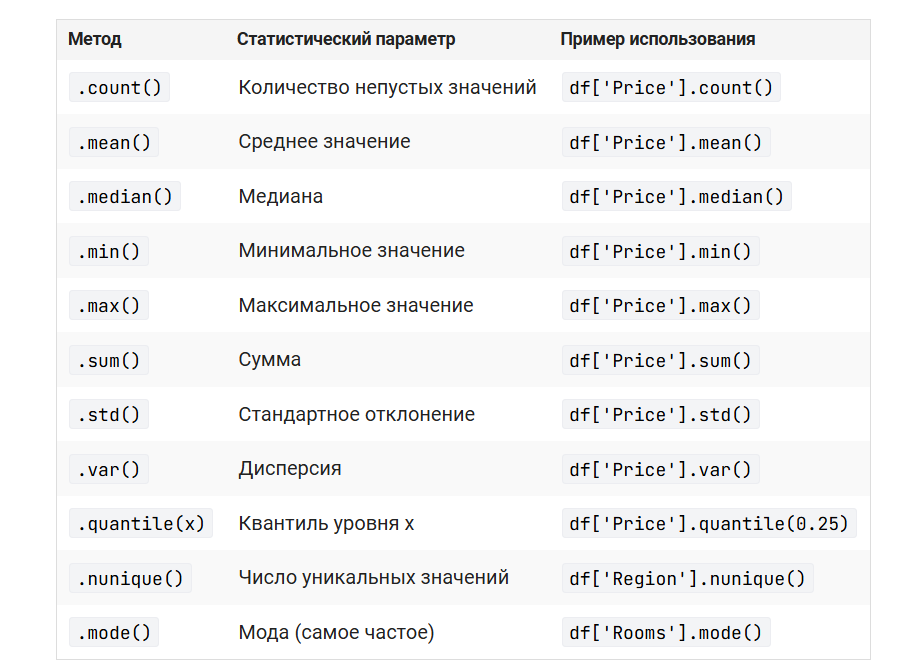

In [24]:
avg_price = melb_data['Price'].mean() #среденее значение
print(f"Средняя цена объектов: ${avg_price:,.2f}")
print(f"Или примерно: ${avg_price:,.0f}")

max_car_spots = melb_data['Car'].max()
print(f"Максимальное количество парковочных мест {max_car_spots}")

#Анализ отклонений: Медиана vs Среднее
landsize_mean = melb_data['Landsize'].mean()
landsize_median = melb_data['Landsize'].median()
print("АНАЛИЗ ПЛОЩАДИ ТЕРРИТОРИИ:")
print("=" * 40)
print(f"Медианная площадь: {landsize_median:,.0f} м²")
print(f"Средняя площадь: {landsize_mean:,.0f} м²")

# Вычисляем относительное отклонение
rd = (abs(landsize_median-landsize_mean)/landsize_mean)
rd_percent = rd*100
print(f"\nОтклонение медианы от среднего: {rd:.2%}")
print(f"Или: {rd_percent:.1f}%")

Средняя цена объектов: $1,067,100.31
Или примерно: $1,067,100
Максимальное количество парковочных мест 10.0
АНАЛИЗ ПЛОЩАДИ ТЕРРИТОРИИ:
Медианная площадь: 440 м²
Средняя площадь: 558 м²

Отклонение медианы от среднего: 21.17%
Или: 21.2%


In [25]:
import numpy as np

max_prcount = melb_data['Propertycount'].max()
print(max_prcount)
std_distance = melb_data['Distance'].std()
print(std_distance)
a = np.array([1, 2, 4, 2, 3, 2, 1, 5, 6])


21650.0
6.062497698504369


БАЗОВЫЕ ОПЕРАЦИИ СО СТОЛБЦАМИ

In [26]:
melb_df = melb_data.copy() #копирование исходного dataframe
melb_df.head()

#удаляем ненужные столбцы
columns_to_drop = ['Unnamed: 0']
print("СТОЛБЦЫ ПЕРЕД УДАЛЕНИЕМ:")
print(f"Количество: {melb_df.shape[1]}")
print(f"Список: {list(melb_df.columns)}")

#способ 1 (создание новой таблицы)
melb_df_clean = melb_df.drop(columns_to_drop,axis=1)
#способ 2 (без создания новой таблицы ОСТРОЖНО!!)
# melb_df.drop(columns_to_drop, axis=1, inplace = True)

print("СТОЛБЦЫ ПОСЛЕ УДАЛЕНИЯ:")
print(f"Количество: {melb_df_clean.shape[1]}")
print(f"Список: {list(melb_df_clean.columns)}")

СТОЛБЦЫ ПЕРЕД УДАЛЕНИЕМ:
Количество: 22
Список: ['Unnamed: 0', 'Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']
СТОЛБЦЫ ПОСЛЕ УДАЛЕНИЯ:
Количество: 21
Список: ['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']


In [27]:
#МАТЕМАТИЧЕСКИ ОПЕРАЦИИ СО СТОЛБЦАМИ (СОЗДАНИЕ НОВЫХ СТОЛБЦОВ)

# Складываем комнаты, спальни и ванные
melb_df['total rooms'] = melb_df['Rooms']+melb_df['Bathroom']

# Делим площадь здания на общее количество комнат
melb_df['MeanRoomsArea'] = melb_df['BuildingArea'] / melb_df['total rooms']

# Cоздадим метрику: насколько здание занимает участок
diff_area = melb_df['BuildingArea'] - melb_df['Landsize']
sum_area = melb_df['BuildingArea'] + melb_df['Landsize']
melb_df['AreaRatio'] = diff_area/sum_area
print(diff_area)

0          NaN
1        -77.0
2         16.0
3          NaN
4         22.0
         ...  
18391      NaN
18392   -709.0
18393      NaN
18394   -250.0
18395      NaN
Length: 14925, dtype: float64


In [28]:
#ВЫЧИСЛЕНИЕ ПЛОТНОСТИ НАСЕЛЕНИЯ И ЕЁ СРЕДНЕГО ЗНАЧЕНИЯ
countries_df = pd.DataFrame({
    'country': ['Англия', 'Канада', 'США', 'Россия', 'Украина', 'Беларусь', 'Казахстан'],
    'population': [56.29, 38.05, 322.28, 146.24, 45.5, 9.5, 17.04],
    'area': [133396, 9984670, 9826630, 17125191, 603628, 207600, 2724902]
})

countries_df['plotnost'] = countries_df['population']*1000000/countries_df['area']
print(countries_df['plotnost'].mean())

84.93080566562001


Преобразования столбцов с помощью метода apply()

In [29]:
print(f'Всего строк: {melb_data.shape[0]}')
print(f'Уникальные адреса {melb_data['Address'].nunique()}')
print(f'Процентное соотношение: {melb_data['Address'].nunique()/melb_data.shape[0]*100:.1f}')

Всего строк: 14925
Уникальные адреса 14709
Процентное соотношение: 98.6


In [30]:
#Функция для извлечения подтипа из адреса
def get_street_type(address):
  exlude_list = ['N','S','W','E']
  address_list = address.split(' ')
  street_type = address_list[-1]
  if street_type in exlude_list:
    street_type = address_list[-2]
  return street_type

street_types = melb_df['Address'].apply(get_street_type)
print(f'Количество уникальных подтипов улиц: {street_types.nunique()}')

# Функция для стандартизации подтипов
def standardize_street_type(stype):
    """Приводит подтипы улиц к стандартному виду"""
    mapping = {
        'Avenue': 'Av',
        'Boulevard': 'Bvd',
        'Parade': 'Pde',
        'Street': 'St',
        'Road': 'Rd',
        'Court': 'Ct',
        'Drive': 'Dr',
        'Grove': 'Gr',
        'Place': 'Pl',
        'Crescent': 'Cr',
        'Close': 'Cl'
    }

    # Приводим к стандартному виду
    for full, short in mapping.items():
        if stype == full or stype == full.upper():
            return short

    return stype

# Применяем стандартизацию ДО группировки
street_types_standardized = street_types.apply(standardize_street_type)

# Выбираем 10 самых частых подтипов
popular_stypes = street_types.value_counts().nlargest(10).index
print(f"Самые популярные подтипы: {list(popular_stypes)}")

# Создаём новый признак
melb_df['StreetType'] = street_types.apply(
    lambda x: x if x in popular_stypes else 'other'
)

print(f"\nТеперь уникальных подтипов: {melb_df['StreetType'].nunique()}")

Количество уникальных подтипов улиц: 60
Самые популярные подтипы: ['St', 'Rd', 'Ct', 'Dr', 'Av', 'Gr', 'Pde', 'Cr', 'Pl', 'Cl']

Теперь уникальных подтипов: 11


In [31]:
#ЗАДАЧИ ДЛЯ ЗАКРПЛЕНИЕ APPLY()
import pandas as pd
import numpy as np

# Создаем DataFrame с информацией о студентах
df = pd.DataFrame({
    'student_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Henry'],
    'math_score': [85, 92, 78, 88, 95, 67, 89, 76],
    'english_score': [78, 85, 88, 92, 79, 84, 91, 82],
    'science_score': [90, 87, 84, 91, 88, 75, 93, 80],
    'attendance': [95, 88, 92, 85, 96, 78, 94, 89],
    'major': ['CS', 'Math', 'CS', 'Physics', 'CS', 'Math', 'Physics', 'CS']
})

#Функция для вычисления среднего и размаха по предматам
def range_and_std(columns):
  return pd.Series({
      'range': columns.max() - columns.min(),
      'std':  columns.std()
  })
result1 = df[['math_score', 'english_score', 'science_score', 'attendance']].apply(range_and_std)


#добавление столбца со средним арифметическим из всех трёх предметов
df['average_score'] = df.apply(lambda row: (row['math_score']+row['english_score']+row['science_score'])/3,axis=1)


#добавление столбца с оценкой (apply с условием)
def status(row):
  clas = ''
  if row['average_score']>=90:
    clas = 'Exelent'
  elif row['average_score']>=80 and row['average_score']<90:
    clas = 'Good'
  elif row['average_score']>=70 and row['average_score']<80:
    clas = 'Satisfactory'
  else:
    clas = 'Needs Improvement'
  return clas
df['performance'] = df.apply(status,axis = 1)


#Функция возврата первой буквы имени
def initials(raw):
  i = list(raw['name'])[0]
  return i
#Функция для приветствия
def greeting(raw):
  return f"Hello, I'm {raw['name']} and my major is {raw['major']}"

df['name_initials'] = df.apply(initials,axis=1)
df['greeting'] = df.apply(greeting, axis = 1)


#Функция для вычисления оценки с учетом весов (дополнительный аргумент в виде словаря)
def calc_weight_score(raw, multiplier_dict):
  avg_score = raw['average_score']
  major = raw['major']
  attendance = raw['attendance']
  weight_score = avg_score * multiplier_dict[major]
  if avg_score>=90 and attendance>=90:
    weight_score+=5
  return weight_score

major_multiplier = {'CS': 1.1, 'Math': 0.95, 'Physics': 1.05}
df['weigheted_score'] = df.apply(calc_weight_score, axis = 1, args = (major_multiplier,))



#метод groupby (объединения по группам)
def group_stat(group):
  return pd.Series({
      'students_count': len(group),
      'avg_math': group['math_score'].mean(),
      'max_attendance': group['attendance'].max(),
      'names': list(group['name'])
  })

res = df.groupby('major').apply(group_stat).reset_index()
res

/tmp/ipykernel_13640/1644902529.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res = df.groupby('major').apply(group_stat).reset_index()


,major,students_count,avg_math,max_attendance,names
0,CS,4,83.5,96,"[Alice, Charlie, Eve, Henry]"
1,Math,2,79.5,88,"[Bob, Frank]"
2,Physics,2,88.5,94,"[Diana, Grace]"


РАБОТА С ДАТАМИ

In [32]:
melb_df['Date'].head()

melb_df['Date'] = pd.to_datetime(melb_df['Date'],dayfirst=True)
melb_df['Date'].head()

#для вычисления разницы между датами
# melb_df['Date'] = pd.to_datetime(melb_df['Date'], format='%d/%m/%Y')
# delta_days = melb_df['Date'] - pd.to_datetime('2016-01-01')
# delta_days

,Date
0,2016-12-03
1,2016-02-04
2,2017-03-04
3,2017-03-04
4,2016-06-04


ОБРАБОТКА КАТЕГОРАЛЬНЫХ ДАННЫХ

In [33]:
print("Память до оптимизации:")
melb_df.info(memory_usage='deep')

Память до оптимизации:
<class 'pandas.core.frame.DataFrame'>
Index: 14925 entries, 0 to 18395
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     14925 non-null  int64         
 1   Suburb         14925 non-null  object        
 2   Address        14925 non-null  object        
 3   Rooms          14925 non-null  int64         
 4   Type           14925 non-null  object        
 5   Price          14925 non-null  float64       
 6   Method         14925 non-null  object        
 7   SellerG        14925 non-null  object        
 8   Date           14925 non-null  datetime64[ns]
 9   Distance       14925 non-null  float64       
 10  Postcode       14925 non-null  float64       
 11  Bedroom2       14925 non-null  float64       
 12  Bathroom       14925 non-null  int64         
 13  Car            14820 non-null  float64       
 14  Landsize       13602 non-null  float64       
 15  B

In [34]:

#посчитаем сколько уникалбных значений в каждом столбце
unique_counts = []
for col in melb_df.columns:
    unique_counts.append({
        'Столбец': col,
        'Уникальных значений': melb_df[col].nunique(),
        'Тип данных': melb_df[col].dtype
    })

unique_df = pd.DataFrame(unique_counts)
unique_df.sort_values('Уникальных значений', inplace=True)
display(unique_df.head(500))

#преобразуем столбцы с малым количеством уникальных занчений в категоральный тип
cols_to_exclude = ['Date', 'Rooms', 'Bedroom', 'Bathroom', 'Car']
max_unique = 150

for col in melb_df.columns:
  if col not in cols_to_exclude and melb_df[col].nunique()<max_unique:
    melb_df[col] = melb_df[col].astype('category')

melb_df.info(memory_usage='deep')

,Столбец,Уникальных значений,Тип данных
4,Type,3,object
6,Method,5,object
20,Regionname,8,object
3,Rooms,9,int64
12,Bathroom,9,int64
13,Car,11,float64
25,StreetType,11,object
11,Bedroom2,12,float64
22,total rooms,15,int64
17,CouncilArea,33,object


<class 'pandas.core.frame.DataFrame'>
Index: 14925 entries, 0 to 18395
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     14925 non-null  int64         
 1   Suburb         14925 non-null  object        
 2   Address        14925 non-null  object        
 3   Rooms          14925 non-null  int64         
 4   Type           14925 non-null  category      
 5   Price          14925 non-null  float64       
 6   Method         14925 non-null  category      
 7   SellerG        14925 non-null  object        
 8   Date           14925 non-null  datetime64[ns]
 9   Distance       14925 non-null  float64       
 10  Postcode       14925 non-null  float64       
 11  Bedroom2       14925 non-null  category      
 12  Bathroom       14925 non-null  int64         
 13  Car            14820 non-null  float64       
 14  Landsize       13602 non-null  float64       
 15  BuildingArea   7762 non-

СОРТИРОВКА ДАННЫХ

In [35]:
import pandas as pd

melb_df = pd.read_csv('data/melb_data_fe.csv')
melb_df.head()

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Longtitude,Regionname,Propertycount,MeanRoomsSquare,AreaRatio,MonthSale,AgeBuilding,WeekdaySale,StreetType,Weekend
0,Abbotsford,2,house,1480000.0,S,Biggin,2016-03-12,2.5,3067,2,...,144.9984,Northern Metropolitan,4019,25.20,-0.231707,3,46,5,St,1
1,Abbotsford,2,house,1035000.0,S,Biggin,2016-04-02,2.5,3067,2,...,144.9934,Northern Metropolitan,4019,15.80,-0.327660,4,116,5,St,1
2,Abbotsford,3,house,1465000.0,SP,Biggin,2017-04-03,2.5,3067,3,...,144.9944,Northern Metropolitan,4019,18.75,0.056338,4,117,0,St,0
3,Abbotsford,3,house,850000.0,PI,Biggin,2017-04-03,2.5,3067,3,...,144.9969,Northern Metropolitan,4019,15.75,0.145455,4,47,0,other,0
4,Abbotsford,4,house,1600000.0,VB,Nelson,2016-04-06,2.5,3067,3,...,144.9941,Northern Metropolitan,4019,17.75,0.083969,4,2,2,St,0


In [36]:

melb_df.sort_values(by='Distance').head(10)
melb_df.sort_values(by='Date', ascending=False)

#сортировка по нескольким столбцам
melb_df.sort_values(by=['Rooms', 'Price']).loc[::5, ['Rooms', 'Price']]

#комбинирование сортировки с фильтрацией
mask1 = melb_df['AreaRatio']<-0.5
mask2 = melb_df['Type'] == 't'
mask3 = melb_df['SellerG'] == 'Nelson'
melb_df[mask1 & mask2 & mask3].sort_values(by=['Date','AreaRatio'], ascending = [True,False], ignore_index=True).loc[:,['Date','AreaRatio']]


,Date,AreaRatio


In [37]:
melb_df.sort_values(by='AreaRatio', ascending=False, ignore_index=True).loc[228,['BuildingArea']]

,228
BuildingArea,82.0


In [38]:
filtred_df = melb_df[melb_df['Rooms']>3]

filtred_df.sort_values(by=['Rooms','MeanRoomsSquare'],
                                   ascending=[True,False],
                                   ignore_index=True).loc[6:8,['Price']]

,Price
6,1350000.0
7,2600000.0
8,1241000.0


МЕТОД GROUPBY

In [56]:
#групируем по типу и применяем функцию поиска среднего для числовых столбцов
melb_df.groupby('Type', as_index=False).mean(numeric_only=True)

#группируем по типу и применяем сфункцию среднего значения к цене
melb_df.groupby('Type')['Price'].mean()

#группируем по региону, находим минимальное расстояние до центра, сортируем по убыванию
melb_df.groupby('Regionname')['Distance'].min().sort_values(ascending=False)

#ГРУППИРОВКА ПО ОДНОМУ КРИТЕРИЮ С НЕСКОЛЬКИМИ АГРЕГАЦИЯМИ
#группируем по месяцу продажи, ищем количество продаж, максимальную и среднее по продажам.сортируем по убыванию количества продаж
melb_df.groupby('MonthSale')['Price'].agg(
    ['count','mean','max']
    ).sort_values(by='count',ascending=False)

#полная информация о всех статистических характеристиках
melb_df.groupby('MonthSale')['Price'].agg('describe')

#получаем множество из агенств недвижимости
melb_df.groupby('Regionname')['SellerG'].agg(['nunique',set])

,nunique,set
Regionname,,
Eastern Metropolitan,26,"{Philip, McGrath, Stockdale, Jellis, Biggin, R..."
Eastern Victoria,11,"{Fletchers, McGrath, HAR, other, Barry, Ray, C..."
Northern Metropolitan,40,"{Village, Philip, McGrath, Stockdale, Nick, Sw..."
Northern Victoria,11,"{McDonald, McGrath, Buckingham, other, HAR, Ra..."
South-Eastern Metropolitan,25,"{McGrath, Chisholm, Stockdale, Jellis, Eview, ..."
Southern Metropolitan,38,"{Philip, McGrath, Williams, Chisholm, Stockdal..."
Western Metropolitan,34,"{Village, McGrath, Williams, Chisholm, Stockda..."
Western Victoria,6,"{HAR, other, Raine, Ray, hockingstuart, YPA}"


In [61]:
melb_df.groupby('Regionname')['Price'].std().sort_values()

melb_df.groupby('Rooms')['Price'].mean().sort_values()

,Price
Rooms,
1,4.338245e+05
2,7.750812e+05
10,9.000000e+05
3,1.076081e+06
4,1.445282e+06
8,1.602750e+06
6,1.849366e+06
5,1.870260e+06
7,1.920700e+06
